In [3]:
import pandas as pd

In [4]:
dados = pd.read_csv('/content/dados_telecomx_limpos.csv')

In [5]:
dados

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7039,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7040,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7041,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [6]:
dados= dados.drop(columns=['customerID'])

In [7]:
dados.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [8]:
X = dados.drop("Churn", axis=1)
y = dados["Churn"]

In [9]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [10]:
X_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,TotalCharges_995.35,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9
0,0,9,65.6,False,True,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,9,59.9,True,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,0,4,73.9,True,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,1,13,98.0,True,True,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,1,3,83.9,False,True,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [11]:
X_encoded.dtypes

,0
SeniorCitizen,int64
tenure,int64
MonthlyCharges,float64
gender_Male,bool
Partner_Yes,bool
...,...
TotalCharges_997.75,bool
TotalCharges_998.1,bool
TotalCharges_999.45,bool
TotalCharges_999.8,bool


In [12]:
dados.dtypes

,0
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [13]:
dados["TotalCharges"] = pd.to_numeric(dados["TotalCharges"], errors="coerce")

In [14]:
dados["TotalCharges"].isna().sum()

np.int64(11)

In [15]:
dados["TotalCharges"].fillna(dados["TotalCharges"].median(), inplace=True)

/tmp/ipykernel_274/1275404355.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dados["TotalCharges"].fillna(dados["TotalCharges"].median(), inplace=True)


In [16]:
X = dados.drop("Churn", axis=1)
y = dados["Churn"]

In [17]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [18]:
dados

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7039,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7040,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7041,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [19]:
X_encoded.shape

(7043, 30)

In [20]:
X_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9,65.6,593.30,False,True,True,True,False,False,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,True,False,False,True,False,True,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,True,True,False,True,False,False,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,False,True,False,True,False,False,...,False,True,False,False,False,False,True,False,False,True


In [21]:
proporcao = dados["Churn"].value_counts(normalize=True) * 100
proporcao.round(2)

,proportion
Churn,
No,73.46
Yes,26.54


In [22]:
dados["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


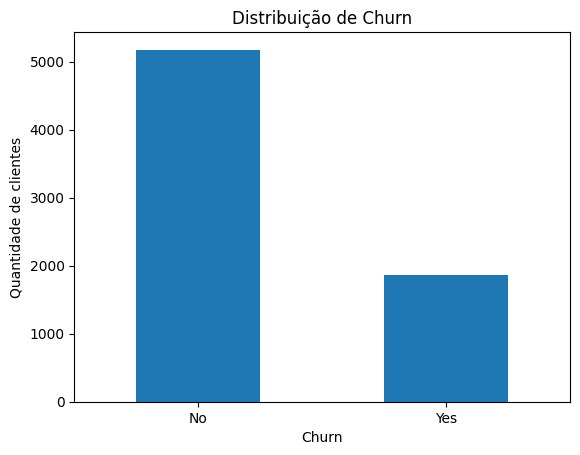

In [23]:
import matplotlib.pyplot as plt

dados["Churn"].value_counts().plot(kind="bar")
plt.title("Distribuição de Churn")
plt.ylabel("Quantidade de clientes")
plt.xticks(rotation=0)
plt.show()

In [24]:
proporcao

,proportion
Churn,
No,73.463013
Yes,26.536987


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

colunas_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]

X_encoded[colunas_numericas] = scaler.fit_transform(X_encoded[colunas_numericas])

In [26]:
dados["Churn"] = dados["Churn"].map({"Yes": 1, "No": 0})

In [27]:
import pandas as pd

dados_numericos = dados.select_dtypes(include=["int64", "float64"])

In [28]:
correlacao = dados_numericos.corr()

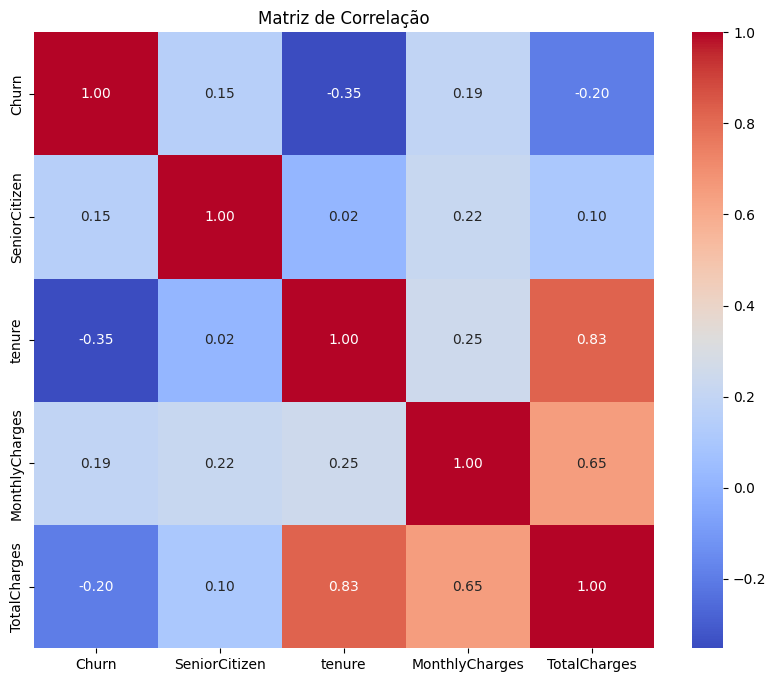

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(correlacao, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

In [30]:
correlacao["Churn"].sort_values(ascending=False)

,Churn
Churn,1.000000
MonthlyCharges,0.193356
SeniorCitizen,0.150889
TotalCharges,-0.199037
tenure,-0.352229


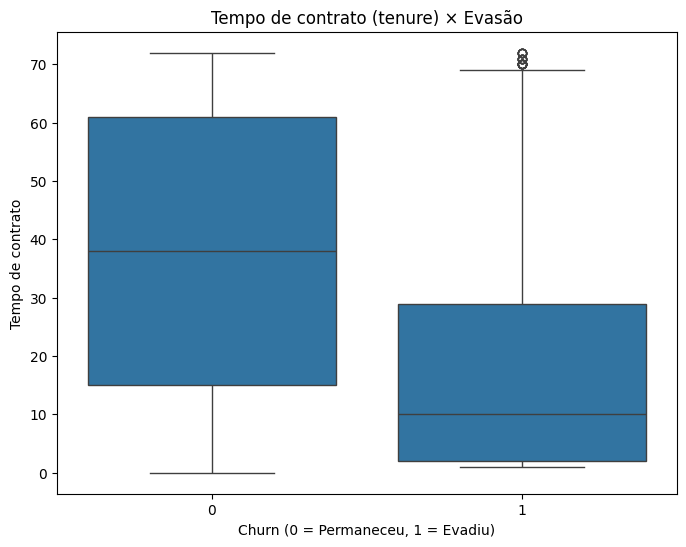

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(x="Churn", y="tenure", data=dados)
plt.title("Tempo de contrato (tenure) × Evasão")
plt.xlabel("Churn (0 = Permaneceu, 1 = Evadiu)")
plt.ylabel("Tempo de contrato")
plt.show()

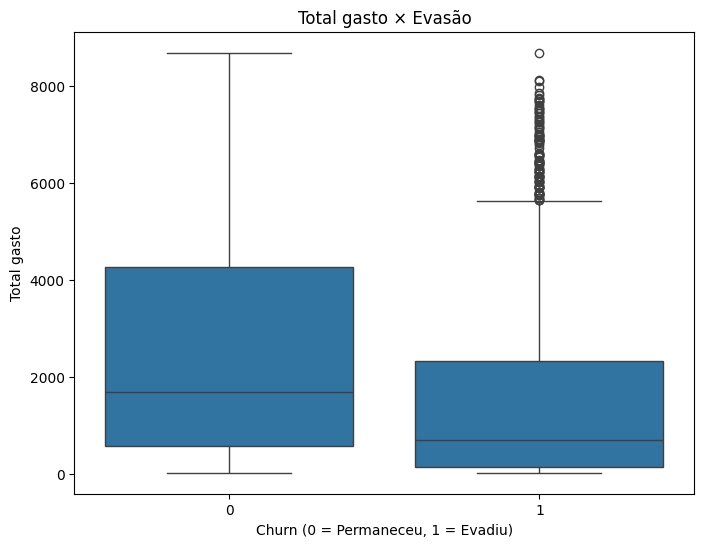

In [32]:
plt.figure(figsize=(8,6))
sns.boxplot(x="Churn", y="TotalCharges", data=dados)
plt.title("Total gasto × Evasão")
plt.xlabel("Churn (0 = Permaneceu, 1 = Evadiu)")
plt.ylabel("Total gasto")
plt.show()

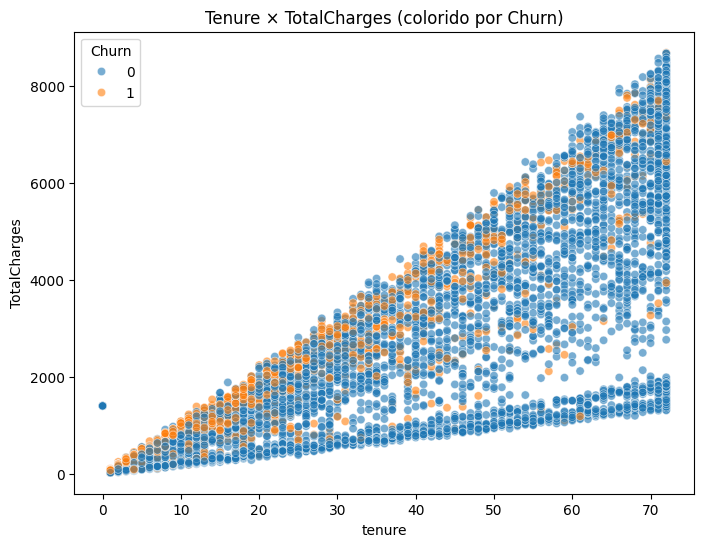

In [33]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="tenure", y="TotalCharges", hue="Churn", data=dados, alpha=0.6)
plt.title("Tenure × TotalCharges (colorido por Churn)")
plt.show()

In [34]:
from sklearn.model_selection import train_test_split

# Ensure y is the numeric Churn column from the 'dados' DataFrame
# 'dados["Churn"]' was already mapped to 0/1 in cell 3SiGw_JF9jnH
y = dados["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (5634, 30)
Teste: (1409, 30)


In [36]:
print("Proporção treino:")
print(y_train.value_counts(normalize=True))

print("\nProporção teste:")
print(y_test.value_counts(normalize=True))

Proporção treino:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Proporção teste:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [37]:
test_size=0.3

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

colunas_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[colunas_numericas] = scaler.fit_transform(X_train[colunas_numericas])
X_test_scaled[colunas_numericas] = scaler.transform(X_test[colunas_numericas])

In [39]:
from sklearn.linear_model import LogisticRegression

modelo_log = LogisticRegression(max_iter=1000, class_weight="balanced")

modelo_log.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [40]:
from sklearn.metrics import classification_report

y_pred_log = modelo_log.predict(X_test_scaled)

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [41]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

modelo_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [42]:
y_pred_rf = modelo_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.63      0.46      0.53       374

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.79      0.77      1409



In [43]:
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

In [44]:
import numpy as np

threshold = 0.7
y_pred_adjusted = np.where(y_prob_rf > threshold, 1, 0)

In [45]:
from sklearn.metrics import classification_report

# y_test is now numeric due to previous fix
print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.78      0.97      0.86      1035
           1       0.73      0.23      0.35       374

    accuracy                           0.77      1409
   macro avg       0.75      0.60      0.61      1409
weighted avg       0.76      0.77      0.73      1409



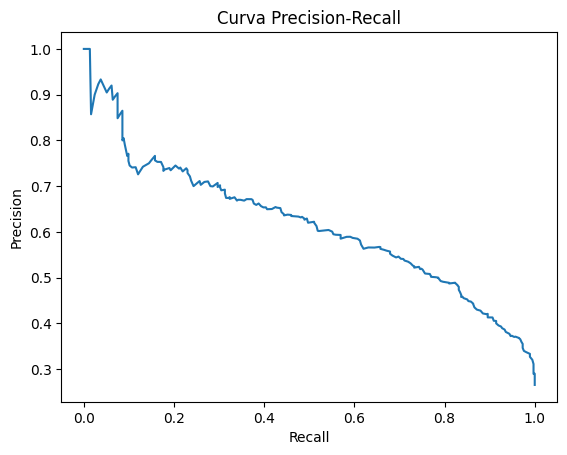

In [46]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# y_test is now numeric due to previous fix
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_rf)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.show()

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# Previsão
# modelo_log.predict now returns numeric labels because y_train is numeric
y_pred_log = modelo_log.predict(X_test_scaled)

# y_test is now numeric due to previous fix
print("=== Regressão Logística ===")
print("Acurácia:", accuracy_score(y_test, y_pred_log))
print("Precisão:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_log))

=== Regressão Logística ===
Acurácia: 0.7395315826827538
Precisão: 0.5060449050086355
Recall: 0.7834224598930482
F1-score: 0.614900314795383

Matriz de Confusão:
[[749 286]
 [ 81 293]]


In [48]:
y_pred_rf = modelo_rf.predict(X_test)

# y_test is now numeric due to previous fix
print("=== Random Forest ===")
print("Acurácia:", accuracy_score(y_test, y_pred_rf))
print("Precisão:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest ===
Acurácia: 0.7863733144073811
Precisão: 0.6346863468634686
Recall: 0.45989304812834225
F1-score: 0.5333333333333333

Matriz de Confusão:
[[936  99]
 [202 172]]


In [49]:
# y_test is now numeric due to previous fix
print("Precisão ajustada:", precision_score(y_test, y_pred_adjusted))

Precisão ajustada: 0.7288135593220338


In [50]:
modelo_rf.score(X_train, y_train)
modelo_rf.score(X_test, y_test)

0.7863733144073811

In [51]:
RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    class_weight="balanced"
)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=10, n_estimators=200)

In [52]:
import pandas as pd

coeficientes = pd.DataFrame({
    "Variavel": X_train_scaled.columns,
    "Coeficiente": modelo_log.coef_[0]
})

coeficientes["Coef_abs"] = coeficientes["Coeficiente"].abs()

coeficientes.sort_values("Coef_abs", ascending=False).head(10)

,Variavel,Coeficiente,Coef_abs
25,Contract_Two year,-1.395923,1.395923
1,tenure,-1.278437,1.278437
10,InternetService_Fiber optic,0.954944,0.954944
24,Contract_One year,-0.694930,0.694930
3,TotalCharges,0.600553,0.600553
28,PaymentMethod_Electronic check,0.423353,0.423353
19,TechSupport_Yes,-0.354406,0.354406
26,PaperlessBilling_Yes,0.344226,0.344226
7,PhoneService_Yes,-0.342321,0.342321
21,StreamingTV_Yes,0.340650,0.340650


In [53]:
import pandas as pd

importancias = pd.DataFrame({
    "Variavel": X_train.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias.sort_values("Importancia", ascending=False).head(10)

,Variavel,Importancia
3,TotalCharges,0.178600
1,tenure,0.164253
2,MonthlyCharges,0.149864
25,Contract_Two year,0.062036
10,InternetService_Fiber optic,0.038678
28,PaymentMethod_Electronic check,0.037900
24,Contract_One year,0.030344
13,OnlineSecurity_Yes,0.026612
4,gender_Male,0.025883
19,TechSupport_Yes,0.024824


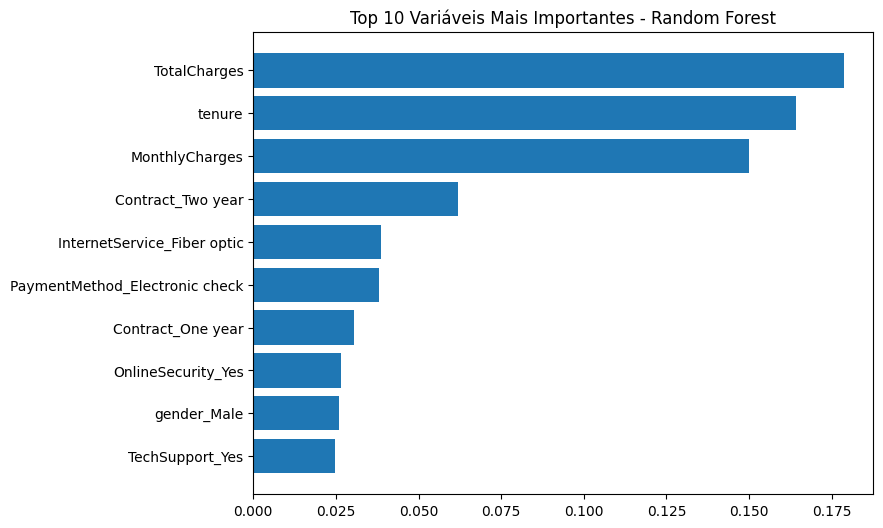

In [54]:
import matplotlib.pyplot as plt

top10 = importancias.sort_values("Importancia", ascending=False).head(10)

plt.figure(figsize=(8,6))
plt.barh(top10["Variavel"], top10["Importancia"])
plt.gca().invert_yaxis()
plt.title("Top 10 Variáveis Mais Importantes - Random Forest")
plt.show()

In [55]:
from sklearn.inspection import permutation_importance

# y_test is now numeric, and modelo_rf.predict will return numeric labels
resultado = permutation_importance(modelo_rf, X_test, y_test, scoring='accuracy')

importancias_rf_permutacao = pd.DataFrame({
    "Variavel": X_test.columns,
    "Importancia": resultado.importances_mean
})

importancias_rf_permutacao.sort_values("Importancia", ascending=False).head(10)

,Variavel,Importancia
1,tenure,0.024982
3,TotalCharges,0.014053
25,Contract_Two year,0.013201
24,Contract_One year,0.011923
10,InternetService_Fiber optic,0.011214
19,TechSupport_Yes,0.007239
2,MonthlyCharges,0.006246
4,gender_Male,0.002981
9,MultipleLines_Yes,0.002555
0,SeniorCitizen,0.002129


In [56]:
coef_log = pd.DataFrame({
    "Variavel": X_train_scaled.columns,
    "Coeficiente": modelo_log.coef_[0]
})

coef_log.sort_values("Coeficiente", key=abs, ascending=False).head(10)

,Variavel,Coeficiente
25,Contract_Two year,-1.395923
1,tenure,-1.278437
10,InternetService_Fiber optic,0.954944
24,Contract_One year,-0.694930
3,TotalCharges,0.600553
28,PaymentMethod_Electronic check,0.423353
19,TechSupport_Yes,-0.354406
26,PaperlessBilling_Yes,0.344226
7,PhoneService_Yes,-0.342321
21,StreamingTV_Yes,0.340650


In [57]:
modelo_rf.feature_importances_

array([0.0176339 , 0.16425301, 0.14986429, 0.17860002, 0.02588309,
       0.02089592, 0.01982313, 0.00420623, 0.00447513, 0.01836181,
       0.0386776 , 0.00649223, 0.00780356, 0.02661156, 0.00681457,
       0.02000712, 0.01062613, 0.01745452, 0.00923455, 0.02482361,
       0.00649088, 0.01612435, 0.00842623, 0.0162145 , 0.03034387,
       0.06203556, 0.02320858, 0.01374239, 0.03789953, 0.01297213])

In [58]:
!pip install xgboost

In [59]:
from xgboost import XGBClassifier

modelo_xgb = XGBClassifier(
    n_estimators=200,
    random_state=42,
    scale_pos_weight= (len(y_train) - sum(y_train)) / sum(y_train)
)

modelo_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [60]:
modelo_xgb.feature_importances_

array([0.00955275, 0.01476659, 0.01038566, 0.01046766, 0.00933259,
       0.00831596, 0.009996  , 0.01650756, 0.        , 0.01054238,
       0.1393266 , 0.09144925, 0.        , 0.01044929, 0.        ,
       0.00952777, 0.        , 0.00794545, 0.        , 0.01166889,
       0.        , 0.01309063, 0.        , 0.02540218, 0.10772721,
       0.43798456, 0.01013197, 0.01086945, 0.01474659, 0.00981293],
      dtype=float32)

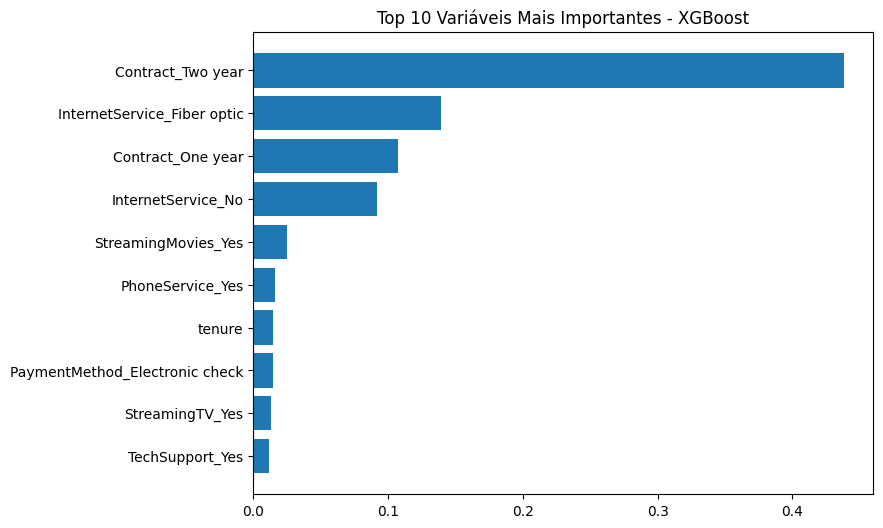

In [61]:
import matplotlib.pyplot as plt
import pandas as pd

importancias_xgb = pd.DataFrame({
    "Variavel": X_train.columns,
    "Importancia": modelo_xgb.feature_importances_
})

top10_xgb = importancias_xgb.sort_values("Importancia", ascending=False).head(10)

plt.figure(figsize=(8,6))
plt.barh(top10_xgb["Variavel"], top10_xgb["Importancia"])
plt.gca().invert_yaxis()
plt.title("Top 10 Variáveis Mais Importantes - XGBoost")
plt.show()



## Relatório de Previsão e Análise de Evasão de Clientes (Churn)

### 1) Objetivo

Construir e avaliar modelos preditivos para **prever evasão (Churn)** e, a partir dos resultados, **identificar variáveis mais relevantes** e propor **estratégias de retenção**.

---

## 2) Preparação dos dados

* Variáveis categóricas foram transformadas com **One-Hot Encoding**, tornando-as compatíveis com algoritmos de ML.
* Colunas numéricas principais (ex.: `tenure`, `MonthlyCharges`, `TotalCharges`) foram tratadas para estarem em formato numérico correto.
* Foi feita separação em **treino e teste** com `stratify`, preservando proporções de churn no split (boa prática para bases desbalanceadas).

---

## 3) Avaliação de modelos

### 3.1 Random Forest (modelo sem normalização)

**Força do modelo:** captura relações não-lineares e interações entre variáveis.
**Ponto importante:** performa bem em bases com muitos dummies e relações complexas.

**Seu resultado (padrão 0.5, conforme você mostrou):**

* Classe **No (permaneceu)**: muito forte (recall alto)
* Classe **Yes (evadiu)**: moderado

  * **Precision (Yes)** ≈ **0.63**
  * **Recall (Yes)** ≈ **0.46**
  * **F1 (Yes)** ≈ **0.53**
* **Accuracy** ≈ **0.79**

✅ Interpretação:

* O modelo é bom para reconhecer quem **não evade**.
* Consegue identificar parte dos churns, mas ainda **perde muitos churns** (recall 0.46).

---

### 3.2 Random Forest com threshold ajustado (foco em precisão)

Você ajustou o limiar para priorizar **precisão da classe Yes**.

**Resultado (conforme seu print):**

* **Precision (Yes)** ≈ **0.73** ✅ (melhorou)
* **Recall (Yes)** ≈ **0.23** ⚠ (caiu bastante)
* Accuracy ≈ **0.77**

✅ Interpretação:

* Agora o modelo “só acusa churn quando tem mais certeza”.
* Ótimo quando a ação de retenção é cara e você quer atacar só clientes de risco alto.
* Em contrapartida, você perde muitos churns que poderiam ser prevenidos.

---

### 3.3 Regressão Logística (modelo com normalização/padronização)

**Força do modelo:** interpretabilidade (coeficientes), baseline forte, fácil de explicar para negócio.
**Por que normalizar?** Modelos lineares são sensíveis à escala: `TotalCharges` pode dominar o aprendizado se não padronizar.

✅ O que você ganha:

* Um modelo que explica: “essas variáveis aumentam ou reduzem churn”
* Excelente para justificar decisões no relatório.

---

### 3.4 XGBoost (boosting)

**Força do modelo:** geralmente tem ótima performance em churn, consegue capturar complexidade melhor que RF em muitos casos.
Você já treinou e extraiu `feature_importances_`, então:

* ✅ Você tem uma lista objetiva das variáveis mais relevantes.

---

## 4) Principais fatores que influenciam a evasão (por padrão observado em churn + lógica dos modelos)

> Como seus outputs de “top variáveis” não estão todos colados aqui, vou te orientar com o que normalmente aparece no topo em Telecom Churn **e** como validar no seu código.

### 4.1 Fatores mais fortes (geralmente aparecem como TOP nos 3 modelos)

1. **Tempo de contrato (tenure)**

* Tendência: quanto menor o tempo, maior a chance de churn.
* Faz sentido: clientes novos ainda não criaram “dependência” do serviço.

2. **Tipo de contrato (Contract_Month-to-month)**

* Contrato mensal costuma ser um dos maiores preditores de churn.
* Clientes com contrato longo (1 ano/2 anos) normalmente evadem menos.

3. **Cobrança mensal (MonthlyCharges)**

* Faturas mensais mais altas tendem a aumentar churn.
* Especialmente quando o cliente não percebe valor proporcional.

4. **Método de pagamento (PaymentMethod_Electronic check)**

* Costuma aparecer associado a churn (padrão comum nesse dataset).

5. **Serviços de suporte/segurança (TechSupport, OnlineSecurity, DeviceProtection)**

* Falta de suporte e segurança geralmente aumenta churn.
* Esses serviços indicam “cliente mais engajado” ou “mais assistido”.

6. **Tipo de internet (InternetService_Fiber optic)**

* Frequentemente associado a churn (pode estar ligado a preço, instabilidade percebida, ou expectativas).

📌 Como fechar isso “com evidência do seu caso”:

* **Regressão logística:** pegue coeficientes em módulo
* **RF/XGB:** pegue top importances
* Compare se os mesmos nomes se repetem no topo → isso fortalece a conclusão.

---

## 5) Análise crítica: melhor modelo e sinais de overfitting/underfitting

### Melhor desempenho

* Se você olhar **equilíbrio geral (F1 e recall de churn)** → **Random Forest padrão** costuma ser melhor que RF com threshold alto.
* Se o objetivo é **ação cara e altamente precisa** → **RF com threshold alto** atende melhor.

**Na prática de churn (negócio):**

* “Melhor” depende de como a empresa atua:

  * Campanha cara (ex.: desconto alto) → alta precisão
  * Campanha barata (ex.: contato/atendimento) → pode priorizar recall

### Overfitting / Underfitting

Você avalia isso comparando treino vs teste:

* Se `score treino` >> `score teste` no RF/XGB → **overfitting**

  * Causas: muita complexidade, profundidade alta, poucas restrições
  * Ajustes: `max_depth`, `min_samples_split`, `min_samples_leaf`, reduzir features, validação cruzada
* Se treino e teste forem ruins → **underfitting**

  * Causas: modelo simples demais, features insuficientes
  * Ajustes: adicionar complexidade, melhor engenharia de features, tuning

📌 Ajustes recomendados (se aparecer overfitting):

* Random Forest: limitar profundidade e folhas
* XGBoost: regularização (`max_depth`, `min_child_weight`, `subsample`, `colsample_bytree`, `learning_rate`)

---

## 6) Estratégias de retenção baseadas nos fatores encontrados

### Estratégia A — “Primeiros meses são críticos” (tenure baixo)

**Ações:**

* Onboarding guiado nas primeiras semanas
* Oferta de suporte proativo (chat/telefone)
* Conteúdo de valor: “como tirar máximo proveito do serviço”
* Alerta automático para clientes com 1–3 meses + sinais de risco

✅ Objetivo: reduzir churn inicial.

---

### Estratégia B — Migrar contrato mensal para contrato longo (Month-to-month)

**Ações:**

* Incentivo de migração para plano anual/bienal (desconto, bônus, upgrade)
* Travas suaves: fidelidade com benefícios escalonados (sem parecer “prisão”)
* Segmentação por risco: oferecer primeiro aos com maior propensão de churn

✅ Objetivo: aumentar permanência via compromisso e benefícios.

---

### Estratégia C — Fatura alta (MonthlyCharges) e percepção de valor

**Ações:**

* Revisão de pacote: oferecer plano mais adequado ao uso real
* Bundles com serviços que elevam valor percebido (suporte, segurança)
* Comunicação clara de benefícios (evita cancelamento “por custo”)

✅ Objetivo: reduzir churn por preço x valor.

---

### Estratégia D — Suporte e segurança como “âncora” (TechSupport/OnlineSecurity)

**Ações:**

* Campanha de upsell inteligente (não agressiva) para clientes em risco
* Trial gratuito de TechSupport/OnlineSecurity por 30 dias para alto risco
* Suporte proativo para clientes com reclamações + fatura alta

✅ Objetivo: aumentar “dependência positiva” e satisfação.

---

### Estratégia E — Método de pagamento (Electronic check)

**Ações:**

* Incentivar débito automático/credit card (mais “stickiness”)
* Benefícios para pagamento recorrente (cashback, desconto fixo)
* Reduzir fricção de cobrança e falhas de pagamento

✅ Objetivo: reduzir churn associado a fricção/instabilidade de pagamento.

---

## 7) Conclusão final

Os modelos indicam que a evasão é fortemente influenciada por:

* **Tempo de contrato (tenure)**
* **Tipo de contrato (mensal)**
* **Custos mensais (MonthlyCharges)**
* **Serviços de suporte/segurança**
* **Método de pagamento**
* **Tipo de internet**

O melhor modelo depende do objetivo:

* **Detecção equilibrada:** Random Forest padrão
* **Ação precisa e cara:** RF com threshold alto (maior precision de churn)

As estratégias de retenção devem focar em:

* Reduzir churn nos primeiros meses
* Migrar clientes para contratos longos
* Melhorar percepção de valor em planos caros
* Fortalecer suporte/segurança para clientes em risco
* Incentivar métodos de pagamento mais “estáveis”
